In [1]:

# import pandas as pd
# from rdkit import Chem
# from rdkit.Chem import PandasTools

# def sdf_to_csv(sdf_file, csv_file):
#     """
#     Convert an SDF file to a CSV file containing isomeric SMILES strings.

#     Parameters:
#     sdf_file (str): Path to the input SDF file.
#     csv_file (str): Path to the output CSV file.
#     """
#     # Load molecules from the SDF file
#     suppl = Chem.SDMolSupplier(sdf_file)
    
#     # Initialize a list to hold data
#     data = []

#     # Iterate over molecules
#     for mol in suppl:
#         if mol is not None:
#             # Extract isomeric SMILES
#             isomeric_smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
#             # Extract molecule name or ID if available
#             mol_name = mol.GetProp('_Name') if mol.HasProp('_Name') else ''
#             # Append to data list
#             data.append([mol_name, isomeric_smiles])

#     # Create a DataFrame
#     df = pd.DataFrame(data, columns=['MoleculeName', 'IsomericSMILES'])

#     # Save to CSV
#     df.to_csv(csv_file, index=False)

# # Example usage
# sdf_to_csv('ChEBI_lite_3star.sdf', 'output.csv')


In [2]:
import os
os.makedirs("benchmarking_results", exist_ok=True)
os.makedirs("benchmarking_results/aromadb", exist_ok=True)
os.makedirs("benchmarking_results/fragrancedb", exist_ok=True)
os.makedirs("benchmarking_results/chebi", exist_ok=True)
os.makedirs("benchmarking_results/flavordb", exist_ok=True)
os.makedirs("benchmarking_results/arctanderdb", exist_ok=True)
os.makedirs("benchmarking_results/sharma_2021db", exist_ok=True)

In [3]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem import Descriptors, Lipinski
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

class MolecularBenchmark:
    def __init__(self, generated_smiles_file=None, generated_smiles_list=None, smiles_column="SMILE"):
        """
        Initialize the benchmarking tool with either a file of SMILES or a list.
        
        Args:
            generated_smiles_file (str): Path to file containing generated SMILES strings
            generated_smiles_list (list): List of generated SMILES strings
            smiles_column (str): Name of the column containing SMILES in the generated file
        """
        self.databases = {
           
            'flavordb': None,
            'fragrancedb': None,
            'chebi': None,
             'aromadb': None,
             'arctander': None,
             'sharma_2021': None
        }
        
        # Load generated molecules
        if generated_smiles_file:
            try:
                df = pd.read_csv(generated_smiles_file)
                if smiles_column in df.columns:
                    self.generated_smiles = df[smiles_column].tolist()
                else:
                    print(f"Column '{smiles_column}' not found in {generated_smiles_file}")
                    print(f"Available columns: {df.columns.tolist()}")
                    self.generated_smiles = []
            except Exception as e:
                print(f"Error loading file {generated_smiles_file}: {e}")
                self.generated_smiles = []
        elif generated_smiles_list:
            self.generated_smiles = generated_smiles_list
        else:
            self.generated_smiles = []
            
        # Convert to RDKit molecules and filter invalid molecules
        self.generated_mols = []
        self.valid_smiles = []
        
        print(f"Attempting to process {len(self.generated_smiles)} generated SMILES...")
        
        for smiles in self.generated_smiles:
            if isinstance(smiles, str):  # Ensure the SMILES is a string
                mol = Chem.MolFromSmiles(smiles)
                if mol:
                    self.generated_mols.append(mol)
                    self.valid_smiles.append(smiles)
        
        print(f"Loaded {len(self.generated_mols)} valid molecules out of {len(self.generated_smiles)} generated SMILES")
    
    def load_database(self, db_name, file_path=None, url=None, smiles_column="IsomericSMILES"):
        """
        Load a reference database for comparison.
        
        Args:
            db_name (str): Name of database ('flavordb', 'fragrancedb', 'chebi')
            file_path (str): Path to local file containing SMILES
            url (str): URL to download database
            smiles_column (str): Name of the column containing SMILES in the database
        """
        if db_name not in self.databases:
            raise ValueError(f"Database {db_name} not supported. Use 'flavordb', 'fragrancedb', or 'chebi'")
        
        smiles_list = []
        
        if file_path:
            # Assume file format as CSV with specified SMILES column
            try:
                df = pd.read_csv(file_path)
                print(f"Available columns in {db_name}: {df.columns.tolist()}")
                
                if smiles_column in df.columns:
                    smiles_list = df[smiles_column].tolist()
                    print(f"Found {len(smiles_list)} SMILES in column '{smiles_column}'")
                else:
                    print(f"Column '{smiles_column}' not found in {db_name}")
                    # Try to find a column that might contain SMILES
                    for col in df.columns:
                        if 'SMILES' in col.upper() or 'SMILE' in col.upper():
                            print(f"Using column '{col}' instead")
                            smiles_list = df[col].tolist()
                            break
            except Exception as e:
                print(f"Error loading file {file_path}: {e}")
                return
        
        elif url:
            # Download from URL
            try:
                response = requests.get(url)
                if response.status_code == 200:
                    df = pd.read_csv(io.StringIO(response.text))
                    
                    if smiles_column in df.columns:
                        smiles_list = df[smiles_column].tolist()
                    else:
                        # Try to find a column that might contain SMILES
                        for col in df.columns:
                            if 'SMILES' in col.upper() or 'SMILE' in col.upper():
                                smiles_list = df[col].tolist()
                                break
            except Exception as e:
                print(f"Error downloading or parsing URL {url}: {e}")
                return
        
        # Convert to RDKit molecules and filter invalid
        mols = []
        valid_smiles = []
        
        print(f"Processing {len(smiles_list)} SMILES from {db_name}...")
        
        for smiles in smiles_list:
            if isinstance(smiles, str):  # Ensure the SMILES is a string
                mol = Chem.MolFromSmiles(smiles)
                if mol:
                    mols.append(mol)
                    valid_smiles.append(Chem.MolToSmiles(mol))  # Canonicalized SMILES
        
        self.databases[db_name] = {
            'smiles': valid_smiles,
            'mols': mols
        }
        
        print(f"Loaded {len(mols)} valid molecules from {db_name}")
        
    def calculate_fingerprints(self, molecules, fp_type='morgan', radius=2, nBits=2048):
        """
        Calculate molecular fingerprints for a list of molecules.
        
        Args:
            molecules (list): List of RDKit molecules
            fp_type (str): Type of fingerprint ('morgan', 'maccs', 'rdkit')
            radius (int): Radius for Morgan fingerprints
            nBits (int): Number of bits for fingerprints
            
        Returns:
            list: List of fingerprints
        """
        fingerprints = []
        
        for mol in tqdm(molecules, desc=f"Calculating {fp_type} fingerprints"):
            if fp_type == 'morgan':
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
            elif fp_type == 'maccs':
                fp = AllChem.GetMACCSKeysFingerprint(mol)
            elif fp_type == 'rdkit':
                fp = Chem.RDKFingerprint(mol, fpSize=nBits)
            else:
                raise ValueError(f"Fingerprint type {fp_type} not supported")
            
            fingerprints.append(fp)
            
        return fingerprints
    
    def calculate_similarity_matrix(self, fps1, fps2):
        """
        Calculate similarity matrix between two sets of fingerprints.
        
        Args:
            fps1 (list): First list of fingerprints
            fps2 (list): Second list of fingerprints
            
        Returns:
            np.array: Similarity matrix
        """
        n1 = len(fps1)
        n2 = len(fps2)
        similarity_matrix = np.zeros((n1, n2))
        
        for i in tqdm(range(n1), desc="Calculating similarity matrix"):
            for j in range(n2):
                similarity_matrix[i, j] = DataStructs.TanimotoSimilarity(fps1[i], fps2[j])
                
        return similarity_matrix
    
    def assess_novelty(self, db_name, similarity_threshold=0.85):
        """
        Assess novelty of generated molecules compared to a database.
        
        Args:
            db_name (str): Name of database to compare against
            similarity_threshold (float): Threshold for considering molecules similar
            
        Returns:
            dict: Dictionary with novelty metrics
        """
        if db_name not in self.databases or self.databases[db_name] is None:
            raise ValueError(f"Database {db_name} not loaded")
            
        print(f"Calculating fingerprints for generated molecules...")
        gen_fps = self.calculate_fingerprints(self.generated_mols)
        
        print(f"Calculating fingerprints for {db_name} molecules...")
        db_fps = self.calculate_fingerprints(self.databases[db_name]['mols'])
        
        print(f"Calculating similarity matrix...")
        similarity_matrix = self.calculate_similarity_matrix(gen_fps, db_fps)
        
        # Find maximum similarity for each generated molecule
        max_similarities = np.max(similarity_matrix, axis=1)
        
        # Count novel molecules (below threshold)
        novel_count = np.sum(max_similarities < similarity_threshold)
        novel_percent = novel_count / len(self.generated_mols) * 100
        
        # Calculate average maximum similarity
        avg_max_similarity = np.mean(max_similarities)
        
        # Find nearest neighbors
        nearest_neighbor_indices = np.argmax(similarity_matrix, axis=1)
        nearest_neighbors = [self.databases[db_name]['smiles'][i] for i in nearest_neighbor_indices]
        
        results = {
            'novel_count': novel_count,
            'novel_percent': novel_percent,
            'avg_max_similarity': avg_max_similarity,
            'max_similarities': max_similarities,
            'nearest_neighbors': nearest_neighbors,
            'nearest_neighbor_indices': nearest_neighbor_indices
        }
        
        print(f"Novelty assessment against {db_name}:")
        print(f"  Novel molecules: {novel_count}/{len(self.generated_mols)} ({novel_percent:.2f}%)")
        print(f"  Average maximum similarity: {avg_max_similarity:.4f}")
        
        return results
    
    def calculate_descriptors(self, molecules):
        """
        Calculate molecular descriptors for a list of molecules.
        
        Args:
            molecules (list): List of RDKit molecules
            
        Returns:
            pd.DataFrame: DataFrame with descriptors
        """
        descriptors = []
        
        for mol in tqdm(molecules, desc="Calculating molecular descriptors"):
            props = {
                'MW': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'HBA': Descriptors.NumHAcceptors(mol),
                'HBD': Descriptors.NumHDonors(mol),
                'TPSA': Descriptors.TPSA(mol),
                'RotBonds': Descriptors.NumRotatableBonds(mol),
                'AromaticRings': Chem.rdMolDescriptors.CalcNumAromaticRings(mol),
                'HeavyAtoms': mol.GetNumHeavyAtoms(),
                'RingCount': Chem.rdMolDescriptors.CalcNumRings(mol)
            }
            descriptors.append(props)
            
        return pd.DataFrame(descriptors)
    
    def compare_property_distributions(self, db_name):
        """
        Compare property distributions between generated molecules and a database.
        
        Args:
            db_name (str): Name of database to compare against
            
        Returns:
            tuple: (generated_descriptors, db_descriptors, combined_descriptors)
        """
        if db_name not in self.databases or self.databases[db_name] is None:
            raise ValueError(f"Database {db_name} not loaded")
            
        print(f"Calculating descriptors for generated molecules...")
        gen_desc = self.calculate_descriptors(self.generated_mols)
        
        print(f"Calculating descriptors for {db_name} molecules...")
        db_desc = self.calculate_descriptors(self.databases[db_name]['mols'])
        
        # Add source column for plotting
        gen_desc['Source'] = 'Generated'
        db_desc['Source'] = db_name
        
        # Combine for plotting
        combined = pd.concat([gen_desc, db_desc])
        
        return gen_desc, db_desc, combined
    
    def plot_property_distributions(self, combined_descriptors, properties=None, save_path=None):
        """
        Plot property distributions.
        
        Args:
            combined_descriptors (pd.DataFrame): Combined descriptors with Source column
            properties (list): List of properties to plot, defaults to all
            save_path (str): Path to save the figure
            
        Returns:
            plt.Figure: Matplotlib figure
        """
        if properties is None:
            properties = ['MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'RotBonds']
        
        n_props = len(properties)
        fig, axes = plt.subplots(n_props, 1, figsize=(10, 4*n_props))
        
        if n_props == 1:
            axes = [axes]
        
        for i, prop in enumerate(properties):
            sns.histplot(data=combined_descriptors, x=prop, hue='Source', kde=True, ax=axes[i])
            axes[i].set_title(f'Distribution of {prop}')
            
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
        return fig
    
    def calculate_validity_metrics(self):
        """
        Calculate validity metrics for generated molecules.
        
        Returns:
            dict: Dictionary with validity metrics
        """
        # Count valid molecules
        validity_rate = len(self.valid_smiles) / len(self.generated_smiles) * 100 if self.generated_smiles else 0
        
        # Check Lipinski's Rule of Five
        ro5_passes = 0
        for mol in self.generated_mols:
            violations = 0
            if Descriptors.MolWt(mol) > 500: violations += 1
            if Descriptors.MolLogP(mol) > 5: violations += 1
            if Descriptors.NumHDonors(mol) > 5: violations += 1
            if Descriptors.NumHAcceptors(mol) > 10: violations += 1
            
            if violations <= 1:  # Allow one violation
                ro5_passes += 1
        
        #ro5_rate = ro5_passes / len(self.generated_mols) * 100 if self.generated_mols else 0
        
        # Check for structural alerts (simplified version)
        def has_structural_alerts(mol):
            # Check for common problematic substructures
            alert_smarts = [
                '[N+](=O)[O-]',  # Nitro group
                'C(=O)N',        # Amide
                'C(=O)O',        # Carboxylic acid
                '[N+]',          # Quaternary nitrogen
                '[S+]',          # Sulfonium
                '[P+]',          # Phosphonium
            ]
            
            has_alert = False
            for smarts in alert_smarts:
                patt = Chem.MolFromSmarts(smarts)
                if mol.HasSubstructMatch(patt):
                    has_alert = True
                    break
            
            return has_alert
        
        alert_count = sum(has_structural_alerts(mol) for mol in self.generated_mols)
        alert_rate = alert_count / len(self.generated_mols) * 100 if self.generated_mols else 0
        
        results = {
            'validity_rate': validity_rate,
            #'lipinski_compliance_rate': ro5_rate,
            'structural_alert_rate': alert_rate
        }
        
        print(f"Validity metrics:")
        print(f"  Validity rate: {validity_rate:.2f}%")
        #print(f"  Lipinski Rule of 5 compliance: {ro5_rate:.2f}%")
        print(f"  Structural alerts present: {alert_rate:.2f}%")
        
        return results
    
    def visualize_chemical_space(self, db_name, method='PCA', n_components=2, save_path=None):
        """
        Visualize chemical space of generated molecules compared to a database.
        
        Args:
            db_name (str): Name of database to compare against
            method (str): Dimensionality reduction method ('PCA' or 'TSNE')
            n_components (int): Number of components
            save_path (str): Path to save the figure
            
        Returns:
            plt.Figure: Matplotlib figure
        """
        if db_name not in self.databases or self.databases[db_name] is None:
            raise ValueError(f"Database {db_name} not loaded")
            
        print(f"Calculating fingerprints for generated molecules...")
        gen_fps = self.calculate_fingerprints(self.generated_mols)
        
        print(f"Calculating fingerprints for {db_name} molecules...")
        db_fps = self.calculate_fingerprints(self.databases[db_name]['mols'])
        
        # Convert fingerprints to numpy arrays
        gen_fp_array = np.zeros((len(gen_fps), gen_fps[0].GetNumBits()))
        db_fp_array = np.zeros((len(db_fps), db_fps[0].GetNumBits()))
        
        for i, fp in enumerate(gen_fps):
            arr = np.zeros((gen_fps[0].GetNumBits(),))
            DataStructs.ConvertToNumpyArray(fp, arr)
            gen_fp_array[i] = arr
            
        for i, fp in enumerate(db_fps):
            arr = np.zeros((db_fps[0].GetNumBits(),))
            DataStructs.ConvertToNumpyArray(fp, arr)
            db_fp_array[i] = arr
            
        # Combine for dimensionality reduction
        combined_fp_array = np.vstack([gen_fp_array, db_fp_array])
        
        # Apply dimensionality reduction
        if method == 'PCA':
            reducer = PCA(n_components=n_components)
        elif method == 'TSNE':
            reducer = TSNE(n_components=n_components, perplexity=min(30, len(combined_fp_array)-1), n_iter=1000)
        else:
            raise ValueError(f"Method {method} not supported. Use 'PCA' or 'TSNE'")
            
        print(f"Applying {method} dimensionality reduction...")
        reduced_data = reducer.fit_transform(combined_fp_array)
        
        # Split back into generated and database
        gen_reduced = reduced_data[:len(gen_fps)]
        db_reduced = reduced_data[len(gen_fps):]
        
        # Create a DataFrame for plotting
        plot_data = pd.DataFrame({
            'x': np.concatenate([gen_reduced[:, 0], db_reduced[:, 0]]),
            'y': np.concatenate([gen_reduced[:, 1], db_reduced[:, 1]]) if n_components > 1 else np.zeros(len(gen_reduced) + len(db_reduced)),
            'Source': ['Generated'] * len(gen_reduced) + [db_name] * len(db_reduced)
        })
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.scatterplot(data=plot_data, x='x', y='y', hue='Source', alpha=0.4, ax=ax)
        
        if method == 'PCA':
            ax.set_xlabel(f'PC1')
            ax.set_ylabel(f'PC2')
        else:
            ax.set_xlabel(f'TSNE1')
            ax.set_ylabel(f'TSNE2')
            
        ax.set_title(f'Chemical Space Visualization - {method}')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
        return fig
    
    def save_benchmarking_results(self, results, output_dir="."):
        """
        Save benchmarking results to files.
        
        Args:
            results (dict): Dictionary with benchmarking results
            output_dir (str): Directory to save results
        """
        import os
        
        # Create output directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Save novelty results
        novelty_df = pd.DataFrame({
            'SMILES': self.valid_smiles,
            'MaxSimilarity': results['novelty']['max_similarities'],
            'NearestNeighbor': results['novelty']['nearest_neighbors']
        })
        novelty_df.to_csv(os.path.join(output_dir, "novelty_results.csv"), index=False)
        
        # Save descriptors
        results['generated_descriptors'].to_csv(os.path.join(output_dir, "generated_descriptors.csv"), index=False)
        results['database_descriptors'].to_csv(os.path.join(output_dir, "database_descriptors.csv"), index=False)
        
        # Save validity metrics
        validity_df = pd.DataFrame([results['validity']])
        validity_df.to_csv(os.path.join(output_dir, "validity_metrics.csv"), index=False)
        
        # Save figures
        results['chemical_space_figure'].savefig(os.path.join(output_dir, "chemical_space.png"), dpi=300, bbox_inches='tight')
        results['property_distribution_figure'].savefig(os.path.join(output_dir, "property_distributions.png"), dpi=300, bbox_inches='tight')
        
        print(f"Results saved to {output_dir}")
    
    def run_full_benchmarking(self, db_name, output_dir=None):
        """
        Run a full benchmarking suite against a database.
        
        Args:
            db_name (str): Name of database to compare against
            output_dir (str): Directory to save results
            
        Returns:
            dict: Dictionary with all benchmarking results
        """
        if db_name not in self.databases or self.databases[db_name] is None:
            raise ValueError(f"Database {db_name} not loaded")
            
        print(f"Running full benchmarking against {db_name}...")
        
        # 1. Novelty assessment
        novelty_results = self.assess_novelty(db_name)
        
        # 2. Property distribution comparison
        gen_desc, db_desc, combined = self.compare_property_distributions(db_name)
        
        # 3. Validity metrics
        validity_results = self.calculate_validity_metrics()
        
        # 4. Chemical space visualization
        chem_space_fig = self.visualize_chemical_space(
            db_name, 
            save_path=output_dir + f"/{db_name}_chemical_space.png" if output_dir else None
        )
        
        # 5. Additional property visualization
        prop_dist_fig = self.plot_property_distributions(
            combined, 
            save_path=output_dir + f"/{db_name}_property_dist.png" if output_dir else None
        )
        
        results = {
            'novelty': novelty_results,
            'generated_descriptors': gen_desc,
            'database_descriptors': db_desc,
            'validity': validity_results,
            'chemical_space_figure': chem_space_fig,
            'property_distribution_figure': prop_dist_fig
        }
        
        # Save results if output directory is provided
        if output_dir:
            import os
            os.makedirs(output_dir, exist_ok=True)
            self.save_benchmarking_results(results, output_dir)
        
        return results



Attempting to process 140 generated SMILES...
Loaded 140 valid molecules out of 140 generated SMILES
Available columns in aromadb: ['CID', 'MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name']
Found 869 SMILES in column 'IsomericSMILES'
Processing 869 SMILES from aromadb...
Loaded 869 valid molecules from aromadb
Available columns in flavordb: ['CID', 'MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name']
Found 25595 SMILES in column 'IsomericSMILES'
Processing 25595 SMILES from flavordb...
Loaded 25595 valid molecules from flavordb
Available columns in fragrancedb: ['Unnamed: 0', 'MolecularWeight', 'IsomericSMILES', 'IUPACName', 'name']
Found 1748 SMILES in column 'IsomericSMILES'
Processing 1748 SMILES from fragrancedb...
Loaded 1748 valid molecules from fragrancedb
Available columns in chebi: ['MoleculeName', 'IsomericSMILES']
Found 52248 SMILES in column 'IsomericSMILES'
Processing 52248 SMILES from chebi...
Loaded 52244 valid molecules from chebi
Available columns in arctan

Calculating morgan fingerprints: 100%|██████████| 140/140 [00:00<00:00, 2741.52it/s]


Calculating fingerprints for aromadb molecules...


Calculating morgan fingerprints: 100%|██████████| 869/869 [00:00<00:00, 3216.14it/s]


Calculating similarity matrix...


...

Calculating morgan fingerprints: 100%|██████████| 140/140 [00:00<00:00, 7646.36it/s]


Calculating fingerprints for arctander molecules...


Calculating morgan fingerprints: 100%|██████████| 2751/2751 [00:00<00:00, 3076.31it/s]


Applying PCA dimensionality reduction...


FileNotFoundError: [Errno 2] No such file or directory: 'benchmarking_results/arctanderdb/arctander_chemical_space.png'

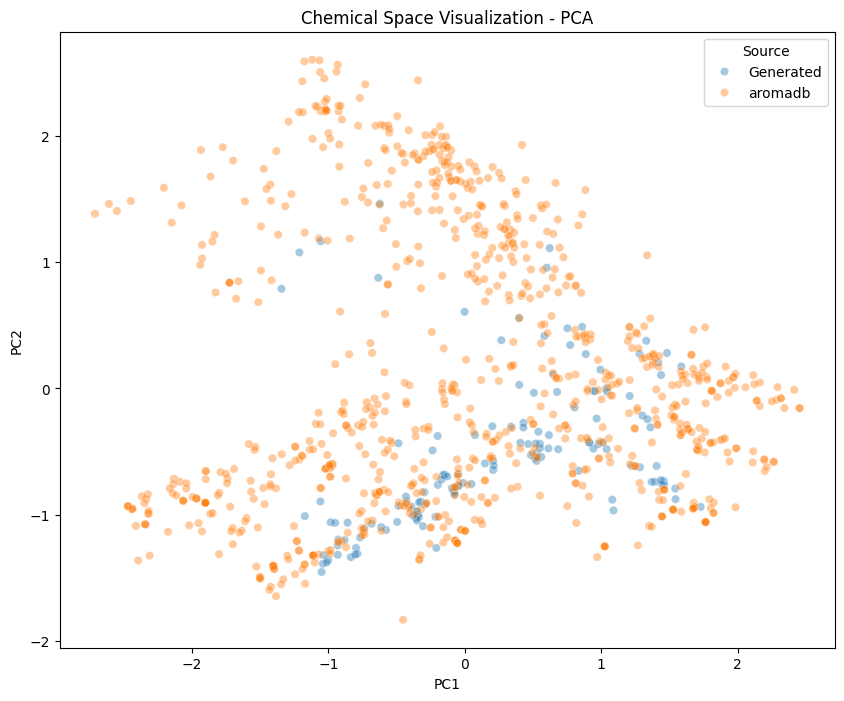

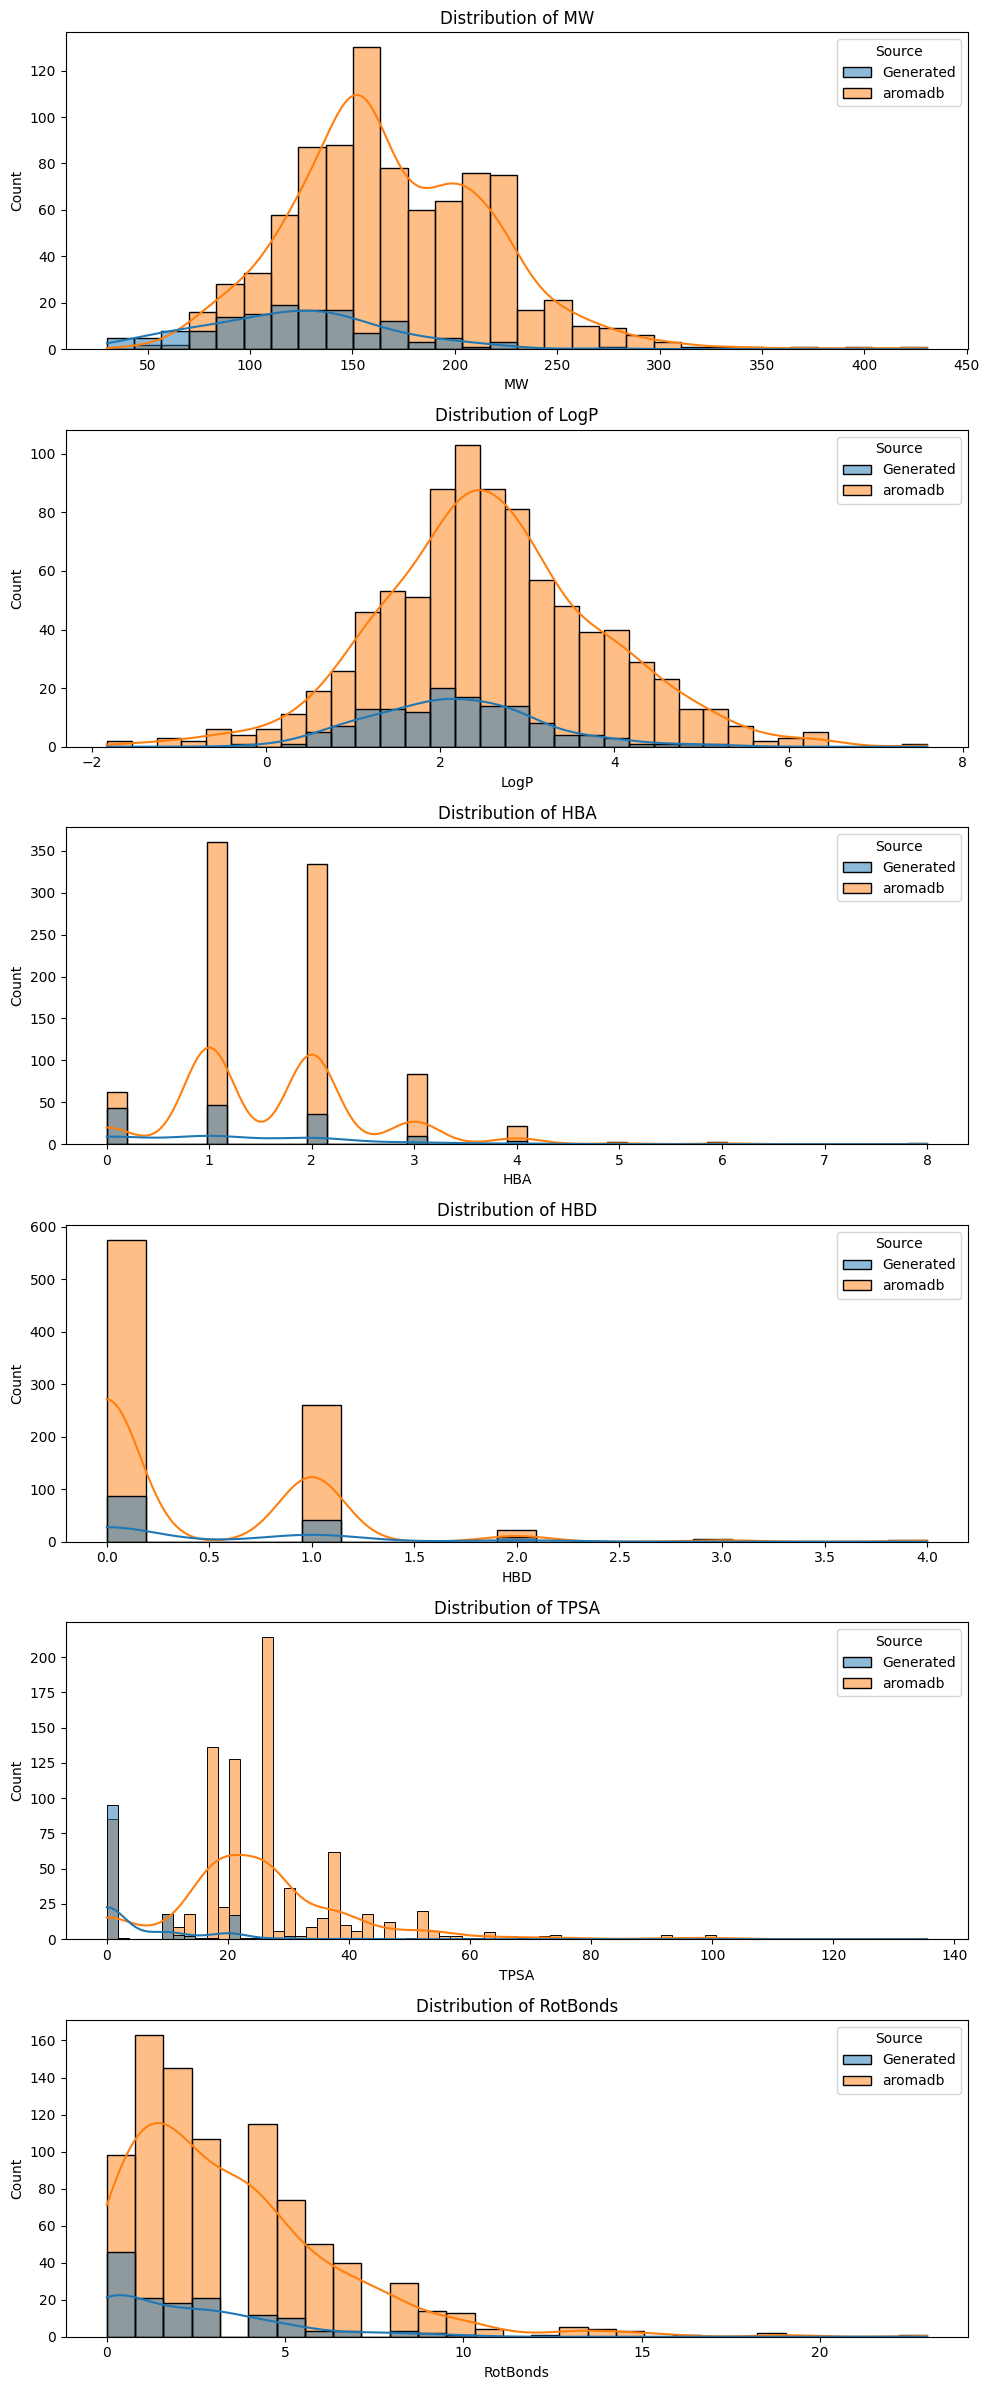

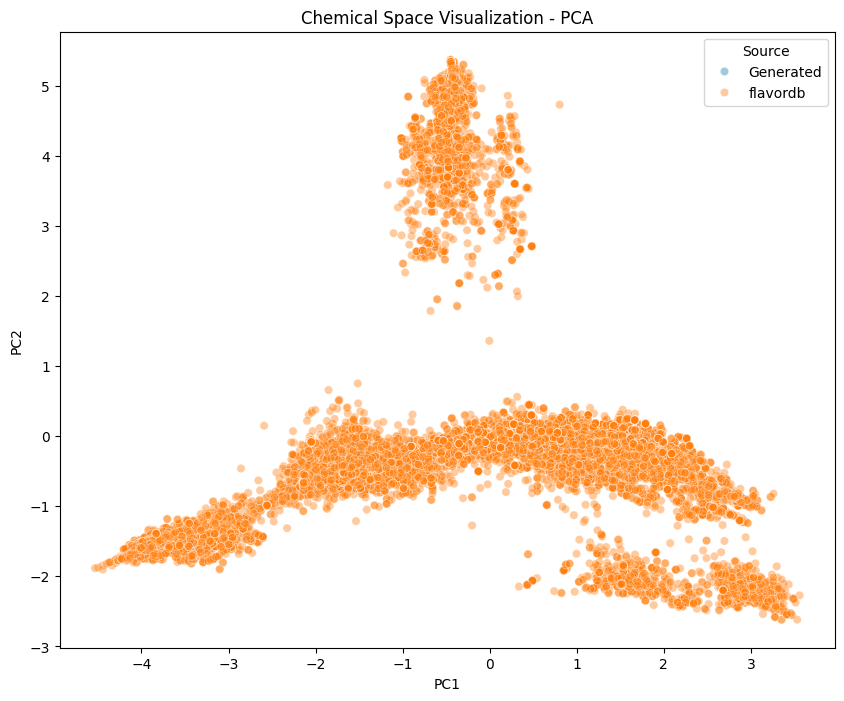

c:\Users\lenovo\anaconda3\envs\genai\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


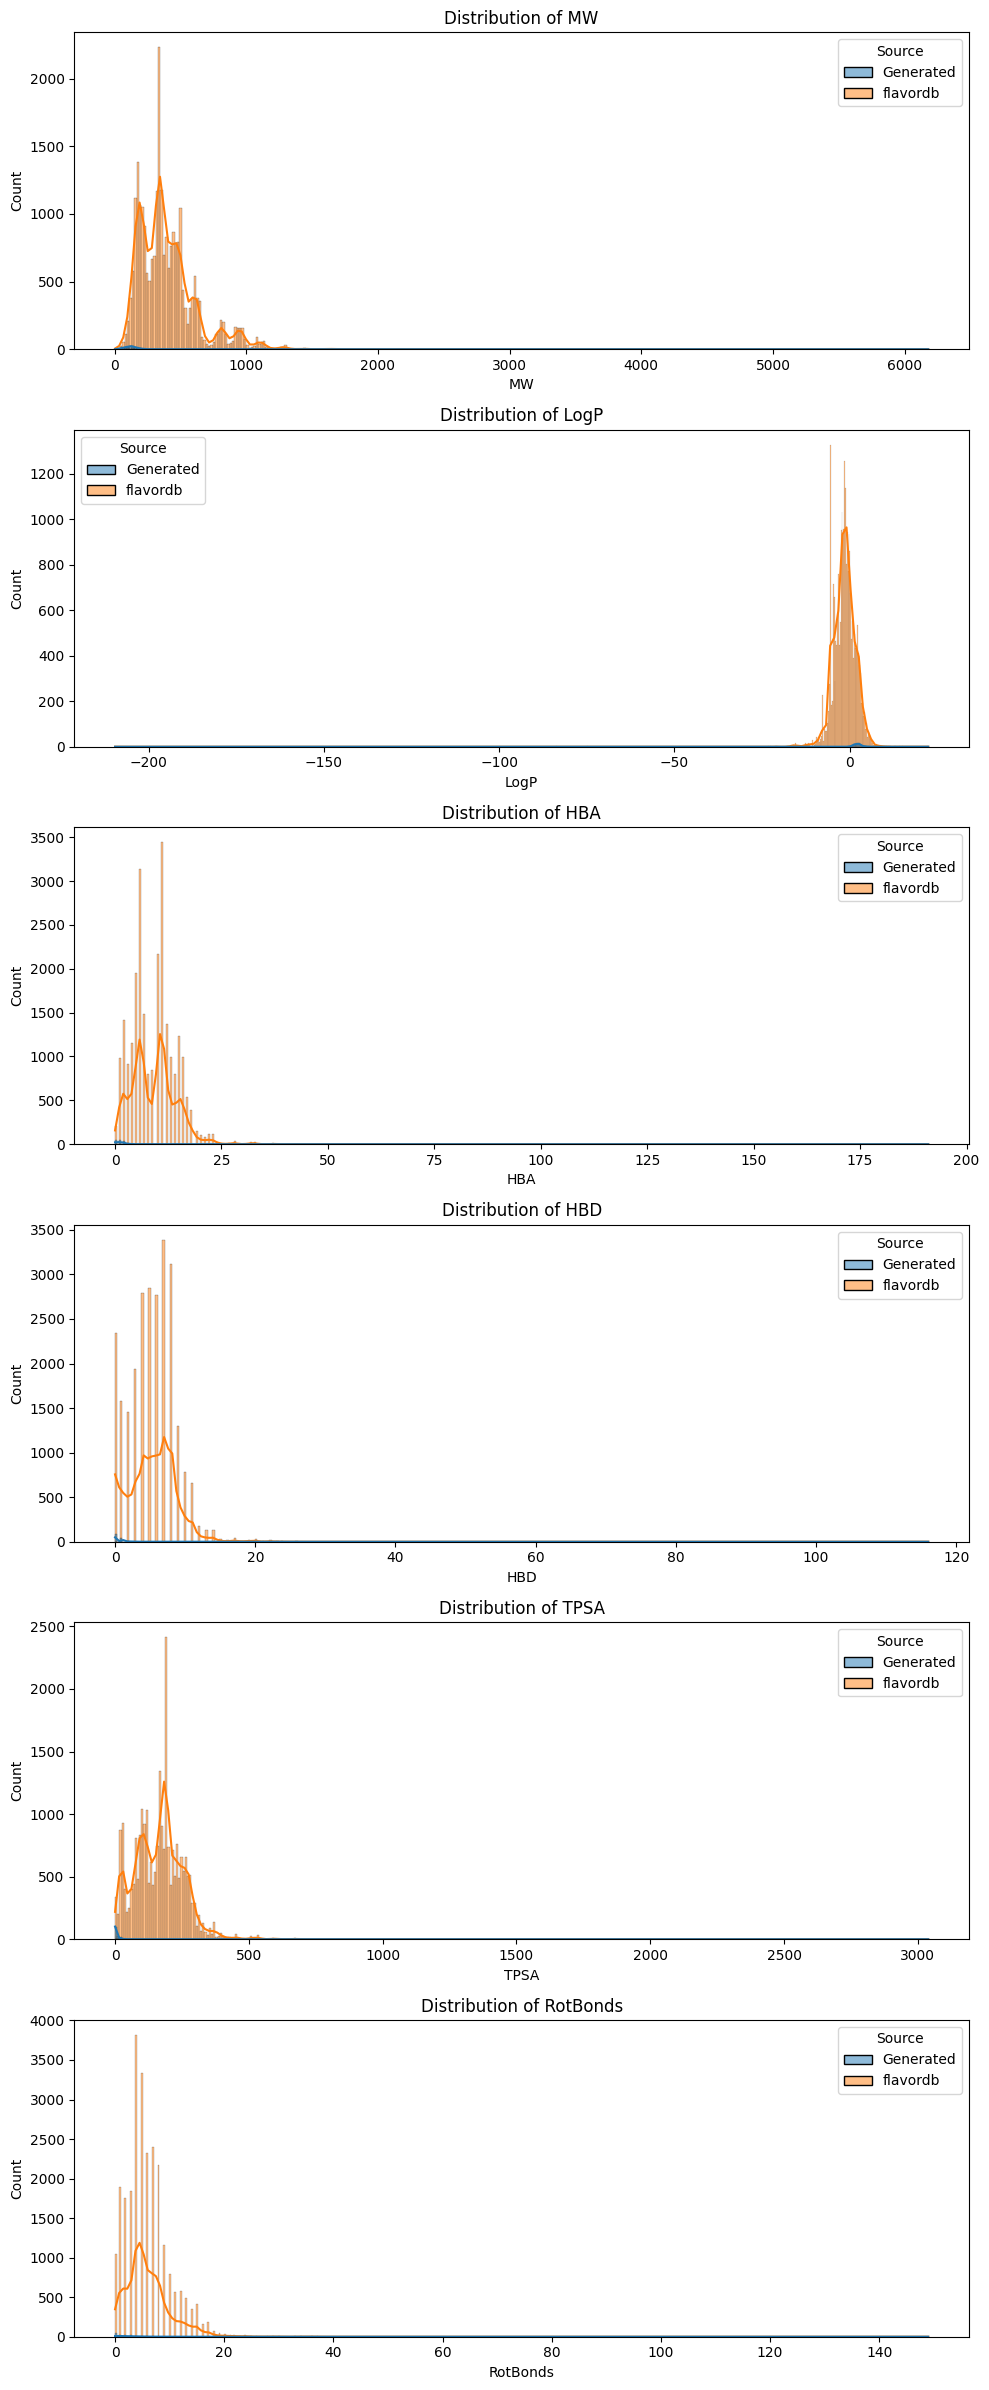

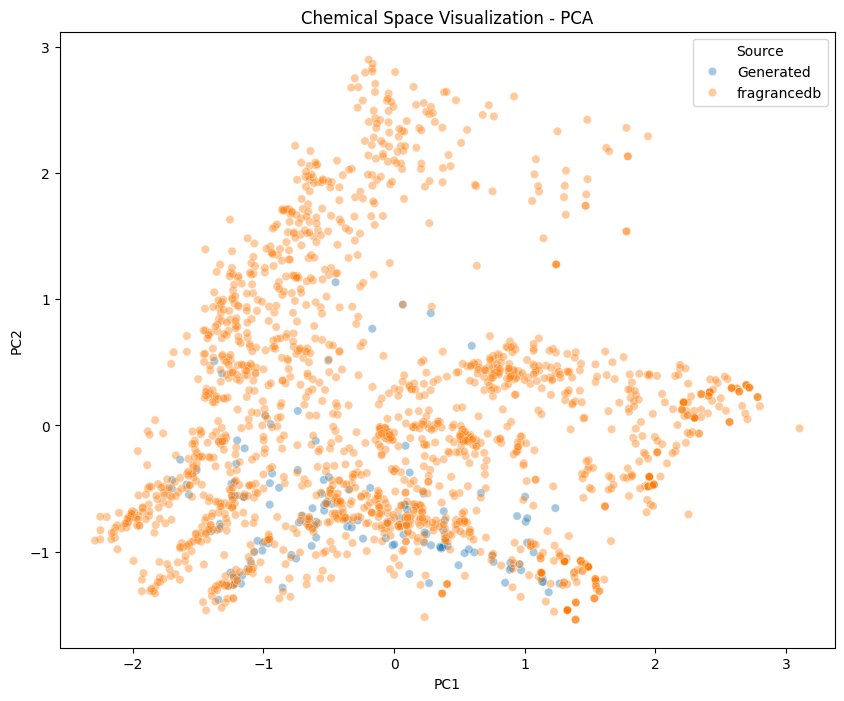

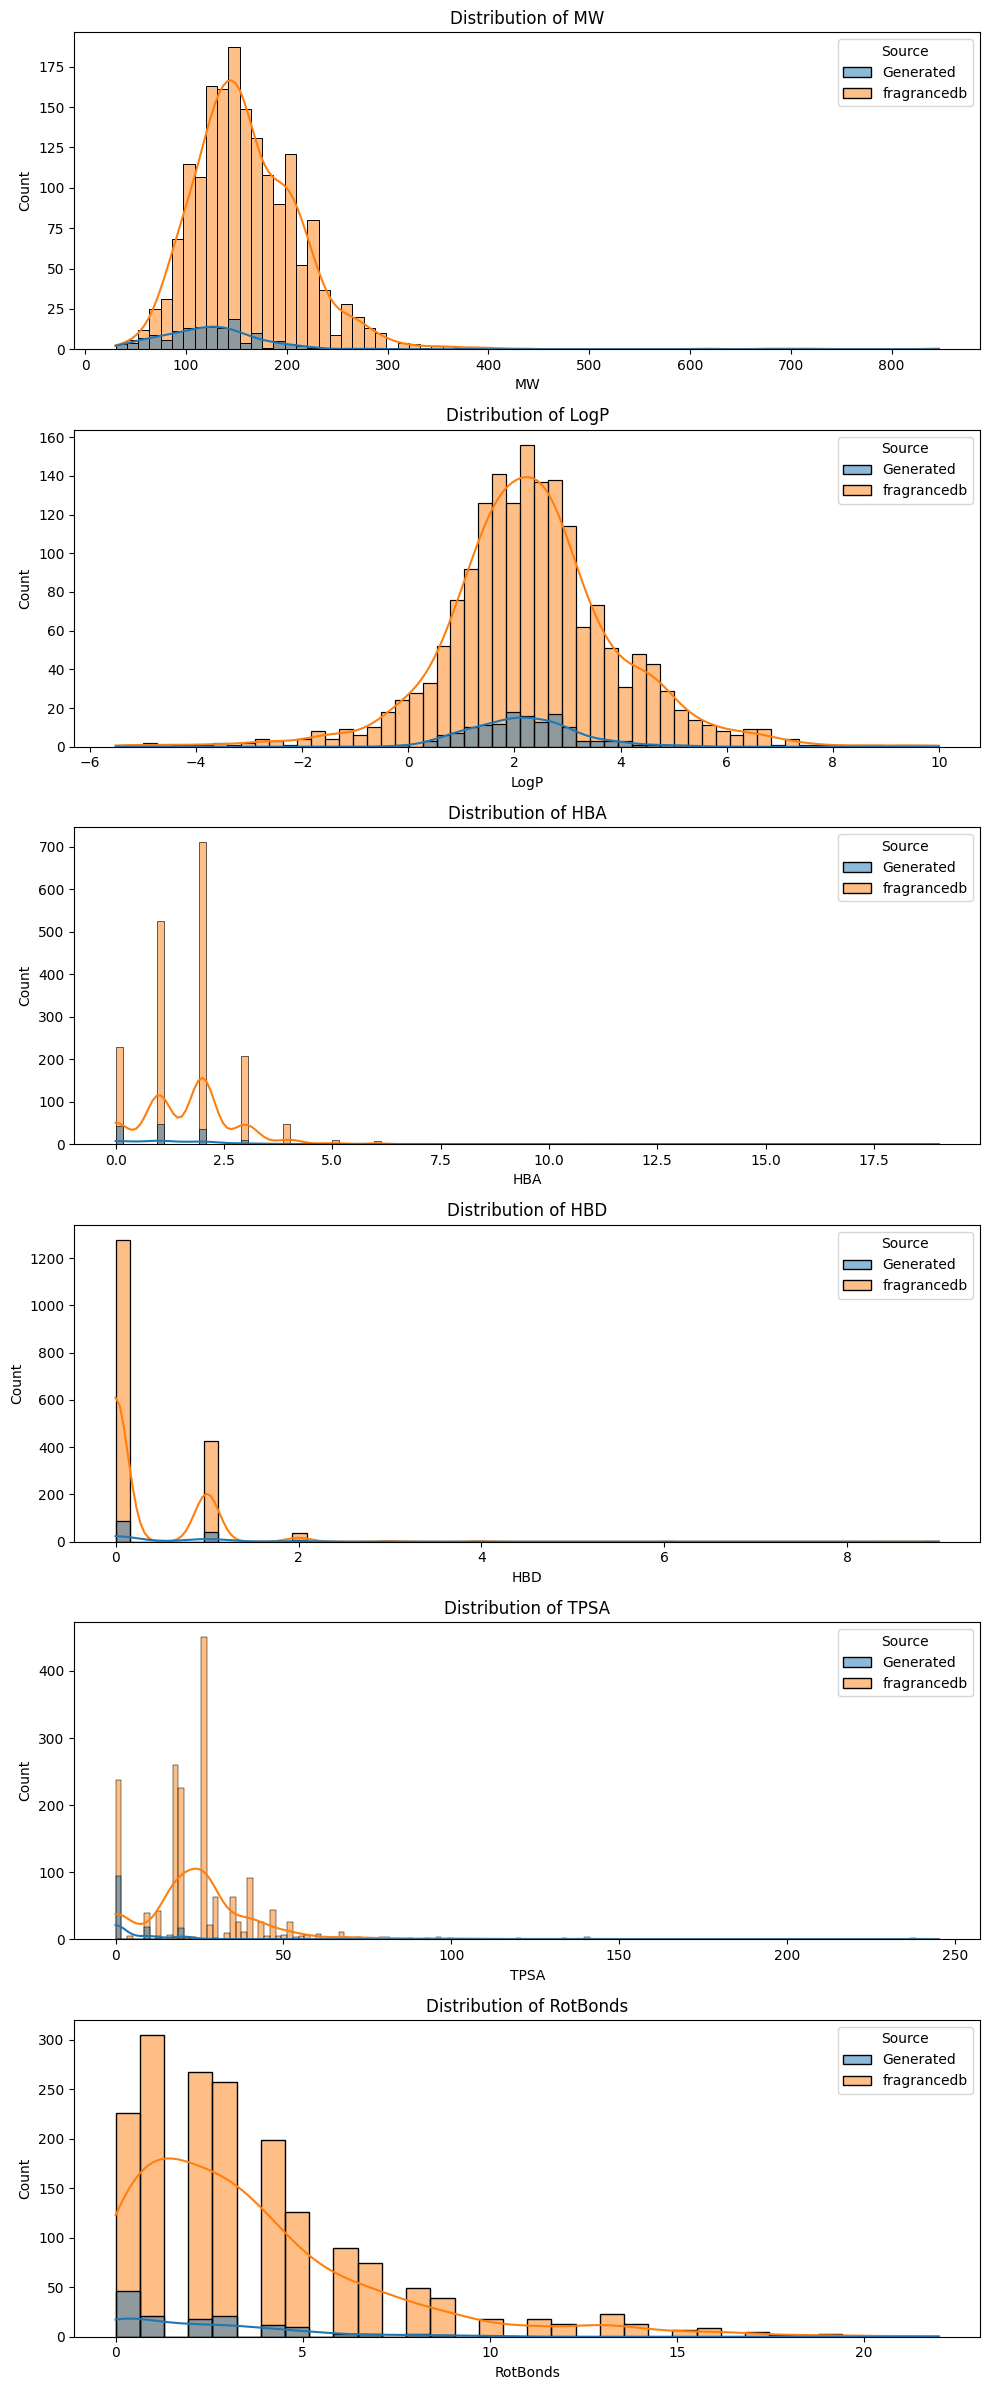

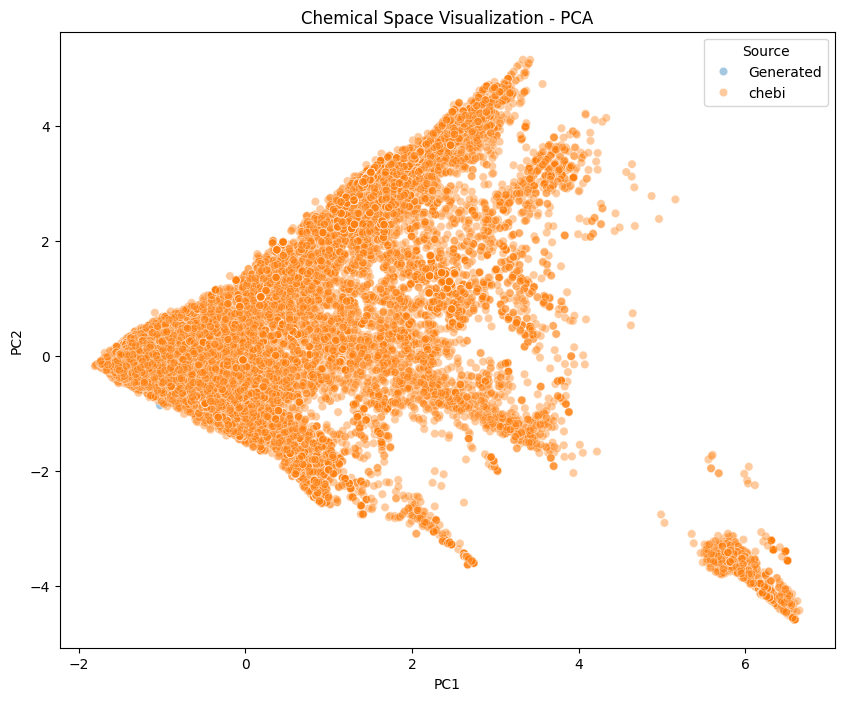

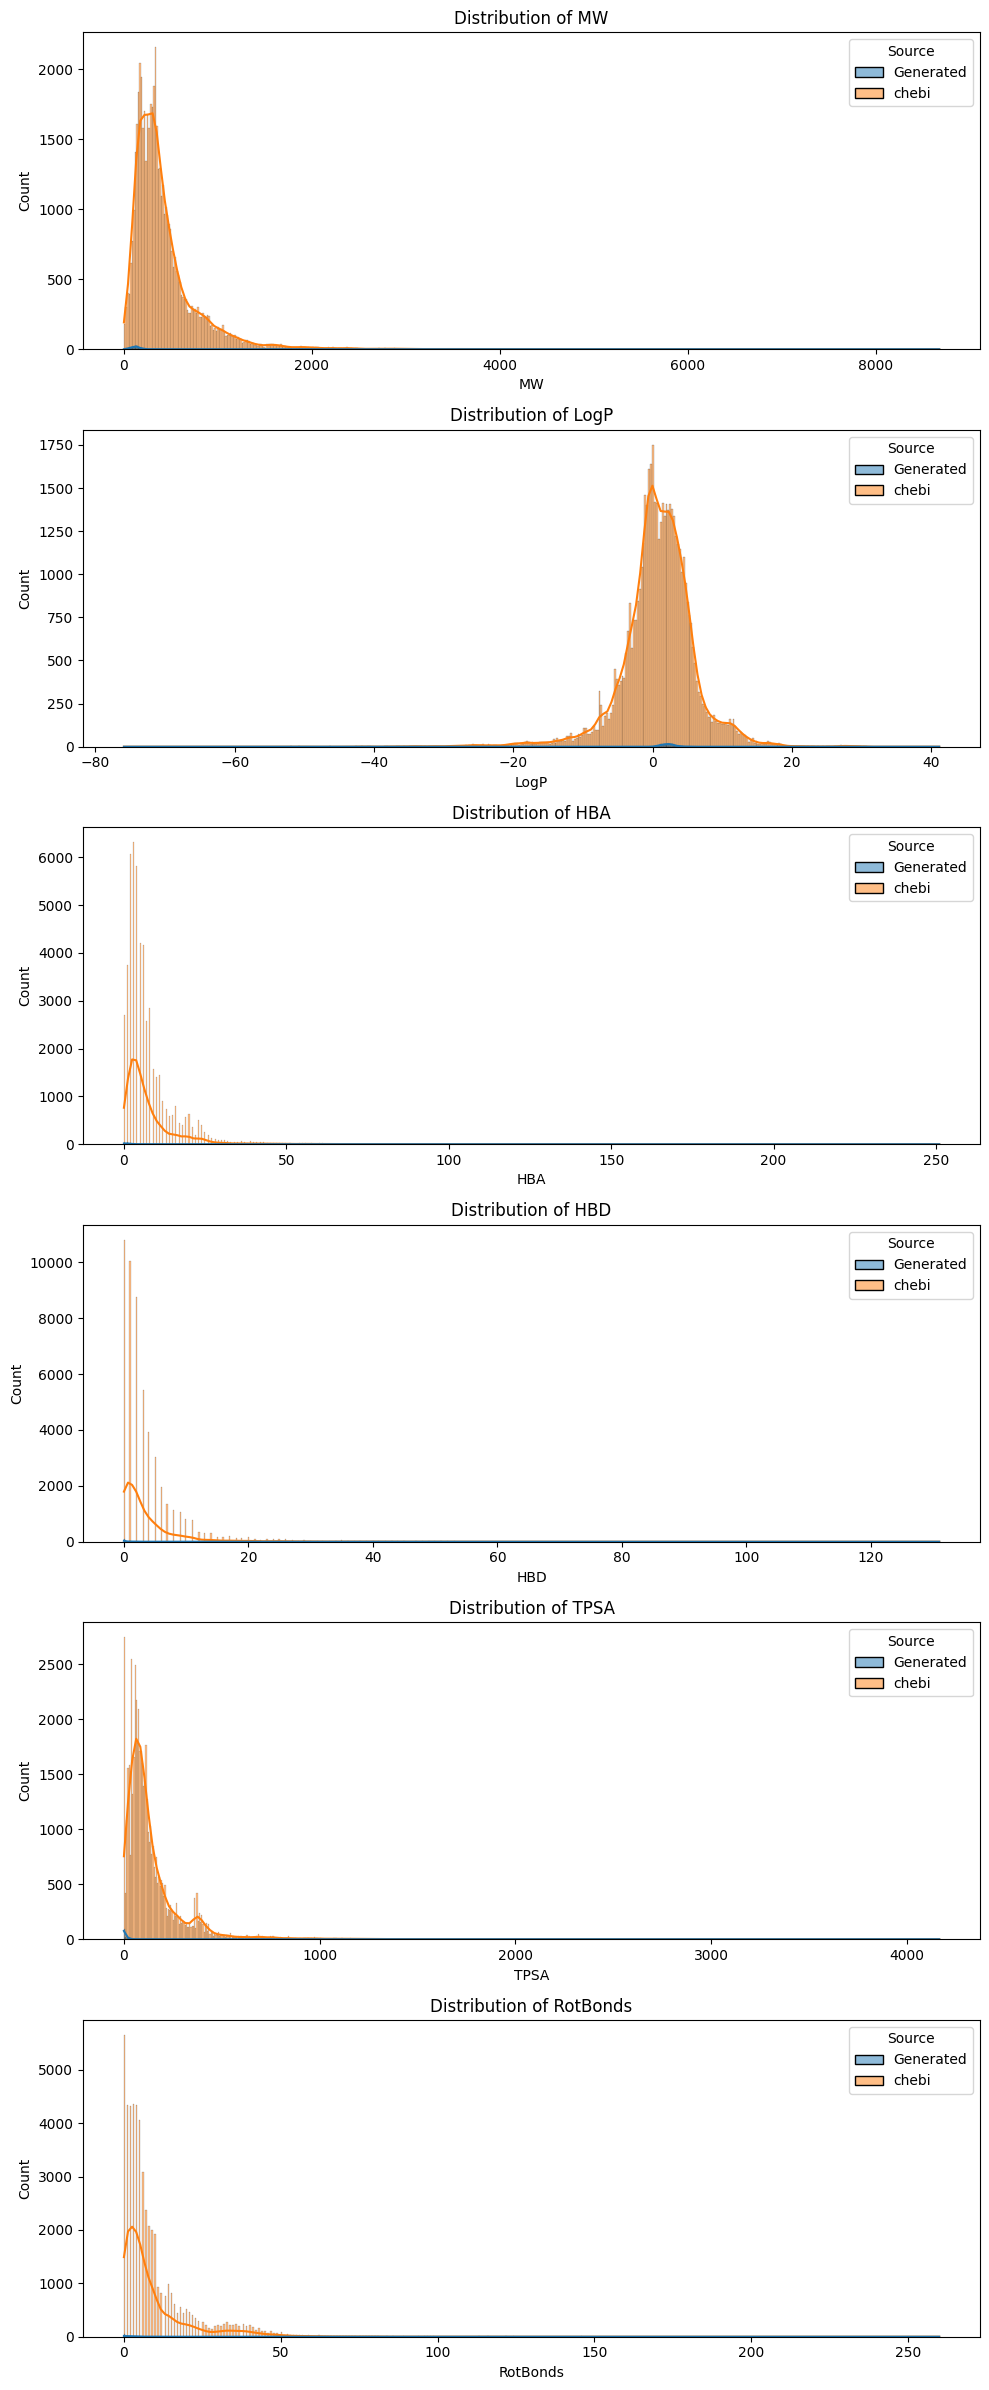

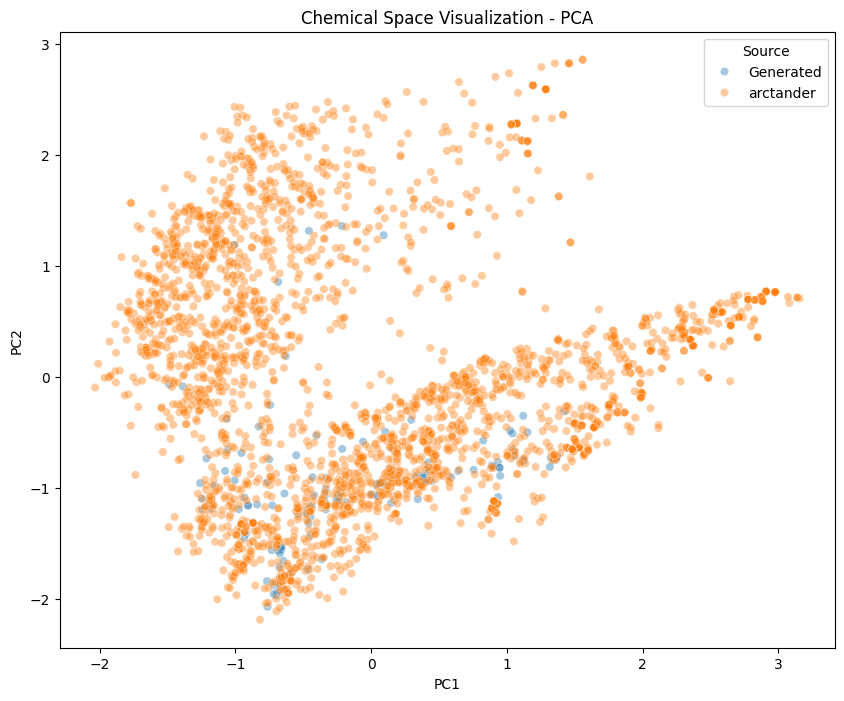

In [4]:
# Example usage with your specific file formats
if __name__ == "__main__":
    # Create a benchmark instance with your generated molecules
    benchmark = MolecularBenchmark(
        generated_smiles_file="filtered_generated_smiles.csv",  # Your file
        smiles_column="SMILE"  # Your SMILES column name
    )
    
    # Load reference databases with IsomericSMILES column
    benchmark.load_database('aromadb', file_path="aromadb_molecules.csv", smiles_column="IsomericSMILES")
    benchmark.load_database('flavordb', file_path="flavordb_molecules.csv", smiles_column="IsomericSMILES")
    benchmark.load_database('fragrancedb', file_path="fragrancedb_molecules.csv", smiles_column="IsomericSMILES")
    benchmark.load_database('chebi', file_path="chebi_molecules.csv", smiles_column="IsomericSMILES") # Create output directories
    benchmark.load_database('arctander', file_path="arctander_molecules.csv", smiles_column="IsomericSMILES")
    benchmark.load_database('sharma_2021', file_path="sharma_2021_molecules.csv", smiles_column="IsomericSMILES")
    aromadb_results = benchmark.run_full_benchmarking(
        'aromadb',
        output_dir="benchmarking_results/aromadb"
    )
    # Run benchmarking against each database
    flavordb_results = benchmark.run_full_benchmarking(
        'flavordb',
        output_dir="benchmarking_results/flavordb"
    )
    
    fragrancedb_results = benchmark.run_full_benchmarking(
        'fragrancedb',
        output_dir="benchmarking_results/fragrancedb"
    )
    chebi_results = benchmark.run_full_benchmarking(
        'chebi',
        output_dir="benchmarking_results/chebi"
    )
    arctander_results = benchmark.run_full_benchmarking(
        'arctander',
        output_dir="benchmarking_results/arctanderdb"
    )
    sharma_2021_results = benchmark.run_full_benchmarking(
        'sharma_2021',
        output_dir="benchmarking_results/sharma_2021db"
    )
    
    # Generate summary report for paper
    summary = {
        'databases': [],
        'total_molecules_in_db': [],
        'novel_molecule_count': [],
        'novel_molecule_percent': [],
        'avg_similarity': []
        #'lipinski_compliance': []
    }
    
    for db, results in [
        ('FlavorDB', flavordb_results),
        ('aromadb', aromadb_results),
        ('FragranceDB', fragrancedb_results),
        ('ChEBI', chebi_results),
        ('arctander', arctander_results),
        ('sharma_2021', sharma_2021_results)
    ]:
        summary['databases'].append(db)
        summary['total_molecules_in_db'].append(len(results['database_descriptors']))
        summary['novel_molecule_count'].append(results['novelty']['novel_count'])
        summary['novel_molecule_percent'].append(results['novelty']['novel_percent'])
        summary['avg_similarity'].append(results['novelty']['avg_max_similarity'])
        #summary['lipinski_compliance'].append(results['validity']['lipinski_compliance_rate'])
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv("benchmarking_results/benchmarking_summary.csv", index=False)
    
    print("Benchmarking complete. Summary report generated.")